In [121]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [122]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

In [123]:
df = pd.read_csv("powerplant_data.csv")


In [124]:
# feature selection
X = df.drop(columns=["PE"])
y=df["PE"]

In [125]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [126]:
y.head()
type(y)  # pandas series
type(X)  # pandas dataframe

pandas.core.frame.DataFrame

In [127]:
# train test split
X_train,X_test,Y_train,Y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [128]:
# scaling our data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # providing the mean and std
X_test_scaled = scaler.transform(X_test)  # nothing provided to avoid data leakage

In [129]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [130]:
X_train.shape
X_test.shape

(1914, 4)

In [131]:
# tranforming the scaled data to tensors
X_train_tensor =torch.tensor(X_train_scaled,dtype=torch.float32)
Y_train_tensor= torch.tensor(Y_train.values,dtype=torch.float32).view(-1,1)  # series in form of (n,) -> series -> ndarray --> shape change
X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
Y_test_tensor= torch.tensor(Y_test.values,dtype=torch.float32).view(-1,1) # series in form of (n,) -> series -> ndarray --> shape change

In [132]:
type(X_train_scaled)   # np.array
type(Y_train)  # panda series
type(Y_train.values) # pandas series --> ndarray
any = Y_train.values
any=any.reshape((-1,1))
any.shape

(7654, 1)

In [133]:
# tensor data --> tensorDataset
train_dataset = TensorDataset(X_train_tensor,Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,Y_test_tensor)

In [134]:
# tensorDataset --> DataLoader(batches)
TrainLoader = DataLoader(train_dataset,batch_size=32,shuffle=True)
TestLoader = DataLoader(test_dataset,batch_size=32)

In [135]:
# Making of our FNN(feedforward Neural Network) Architecure
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()
    self.model=nn.Sequential(
        # input layer of model
        nn.Linear(
            in_features=X_train.shape[1],
            out_features=6
        ),
        nn.ReLU(),

        # 1st hidden layer
        nn.Linear(
            in_features=6,
            out_features=6
        ),
        nn.ReLU(),

        # 2nd hiddern layer
        nn.Linear(
            in_features=6,
            out_features=1
        )
    )
  def forward(self,x):
    return self.model(x)

In [136]:
model = ANN()
optimizer = optim.Adam(model.parameters())
criterion = nn.MSELoss();

In [137]:
# training out model with iteration
best_val_loss = float("inf")
epochs = 100
train_loss = []
validation_loss = []
for epoch in range(epochs):
  model.train();
  running_loss = 0.0
  for xb,yb in TrainLoader:
    optimizer.zero_grad()
    output=model(xb)
    loss = criterion(output,yb)
    loss.backward()
    optimizer.step()
    running_loss +=loss.item()
  average_per_epoch_loss = running_loss/len(TrainLoader)
  train_loss.append(loss.item())
  # print(f'trainig loss for {epoch+1}/{epochs} are  {loss}')

  # validation in TestLoader;
  model.eval()
  running_val_loss=0.0
  with torch.no_grad():
    for xb,yb in TestLoader:
      output=model(xb)
      val_loss = criterion(output,yb)
      running_val_loss +=val_loss.item()
    average_val_loss = running_val_loss/len(TrainLoader)
    validation_loss.append(val_loss.item())
  # print(f'trainig loss for {epoch+1}/{epochs} are  {loss} val loss {val_loss}
  if best_val_loss > val_loss:
    best_val_loss = val_loss
    torch.save(model.state_dict(),"powerplantbestmodel.pt")

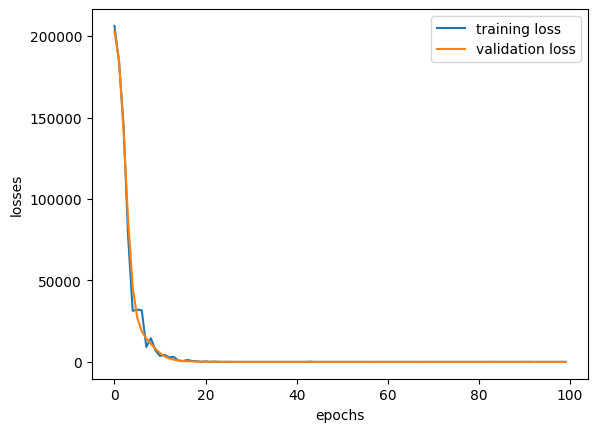

In [138]:
Data = pd.DataFrame({
    "training_loss":train_loss,
    "validation_loss":validation_loss,
})
plt.plot(Data["training_loss"],label="training loss")
plt.plot(Data["validation_loss"],label="validation loss")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.legend()

In [139]:
model.load_state_dict(torch.load("powerplantbestmodel.pt"))

<All keys matched successfully>

In [140]:
len(train_loss)

100

In [141]:
model.eval()
with torch.no_grad():
  # output
  train_pred = model(X_train_tensor)
  test_pred = model(X_test_tensor)
  # loss
  train_loss = criterion(train_pred,Y_train_tensor)
  test_loss = criterion(test_pred,Y_test_tensor)

In [142]:
from sklearn.metrics import r2_score
print(f'training accuracy : {r2_score(Y_train_tensor,train_pred)*100}%')
print(f'testing accuracy : {r2_score(Y_test_tensor,test_pred)*100}%')

print(f'MSE training loss : {train_loss.item()}')
print(f'MSE testing loss : {test_loss.item()}')


training accuracy : 90.22589471070305%
testing accuracy : 90.0629385688087%
MSE training loss : 28.59140396118164
MSE testing loss : 28.434316635131836


In [143]:
train_pred.shape

torch.Size([7654, 1])

In [144]:
Y_train_tensor.shape

torch.Size([7654, 1])

In [145]:
training_pred=train_pred.numpy()
training_actual=Y_train_tensor.numpy()
training_data = pd.DataFrame({
    "training_pred":training_pred.flatten(), # need list of element (n,1) is 2 dim (n,) is 1 dim to make dataframe we need 1 dim array
    "training_actual":training_actual.flatten()
})
training_data

,training_pred,training_actual
0,442.528748,442.750000
1,435.977142,432.519989
2,435.063721,428.799988
3,429.291626,426.070007
4,433.181702,436.579987
...,...,...
7649,440.931946,436.440002
7650,436.797302,441.200012
7651,461.966370,464.260010
7652,438.220032,440.450012


In [146]:
testing_data=pd.DataFrame({
    "testing_pred":test_pred.numpy().flatten(),
    "testing_actual":Y_test_tensor.numpy().flatten()
})
testing_data

,testing_pred,testing_actual
0,437.303436,433.269989
1,437.478912,438.160004
2,461.869141,458.420013
3,475.957886,480.820007
4,437.301270,441.410004
...,...,...
1909,451.826416,456.700012
1910,433.310242,438.040009
1911,467.020721,467.799988
1912,432.470764,437.140015
